# demiwtg 数据质量分析

数据源：三机分片清单（A: docs/image-shard-0, B: docs/image-shard-1, 本机: docs/image-shard-2）+ 共享盘页文件。

运行方式：在本机（10.3.0.14）venv 里跑；第 1 格会经 ssh 拉取 A/B 最新清单（失败则退回上次镜像）。

产出：docs 域名/权威分布、段落绑定质量、壳页抽样、图像源分布与重复检测、概念覆盖交叉、商业域复核清单。

In [2]:
def load(pattern):
    rows = []
    for p in sorted(WORK.glob(pattern)):
        tag = next(t for t, (_, d, i) in SOURCES.items() if d == p.name or i == p.name)
        for line in open(p):
            try:
                r = json.loads(line); r['_shard'] = tag; rows.append(r)
            except Exception: pass
    return pd.DataFrame(rows)

docs = load('docs-shard-*.jsonl')
imgs = load('image-shard-*.jsonl')
docs['domain'] = docs['url'].map(lambda u: urlparse(u).netloc)
print(f'docs {len(docs)} 行（页级去重后 {docs.page_sha.nunique()}）｜ images {len(imgs)} 行')
docs.head(3)

docs 6161 行（页级去重后 2532）｜ images 16835 行


,page_sha,url,concepts,authority,title,path,n_passages,n_images,query,fetched_at,_shard,domain
0,1cc977f1b677d4da3f7c97c43e357abc50bb1f25c24e02...,https://en.wikipedia.org/wiki/NAO,[软银 NAO],wiki,NAO,pages/1c/1cc977f1b677d4da3f7c97c43e357abc50bb1...,25,0,NAO,1.788693e+09,A(0/3),en.wikipedia.org
1,b5893ce94a5808402e1dcddba1a5b126dd0f4cdb0b6f6a...,https://www.roboatlas.ai/zh-CN/products/nao,[软银 NAO],serp,软银机器人 Nao 人形机器人参数、价格与开发支持 ...,pages/b5/b5893ce94a5808402e1dcddba1a5b126dd0f4...,2,7,软银 NAO,1.788693e+09,A(0/3),www.roboatlas.ai
2,40ca63f32e52cc4e4a82a3cf986e00808ec6764d71c0fd...,https://baike.baidu.com/item/NAO/18025769,[软银 NAO],serp,NAO（仿人智能机器人）_百度百科,pages/40/40ca63f32e52cc4e4a82a3cf986e00808ec67...,9,2,软银 NAO,1.788693e+09,A(0/3),baike.baidu.com


## 1. docs 域名分布与权威结构

In [1]:
import json, os, subprocess, shutil
from pathlib import Path
from urllib.parse import urlparse
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

WORK = Path('/tmp/kilo/quality'); WORK.mkdir(parents=True, exist_ok=True)
PAGES_ROOT = Path('/lhcos-data/demiwtg-data/datasets/demiwtg/pages')
LOCAL_META = Path('/home/ubuntu/lake/meta')

SOURCES = {
    'A(0/3)':  ('pipeline-a', 'docs-shard-0-of-3.jsonl', 'image-shard-0-of-3.jsonl'),
    'B(1/3)':  ('pipeline-b', 'docs-shard-1-of-3.jsonl', 'image-shard-1-of-3.jsonl'),
    '本机(2/3)': (None, 'docs-shard-2-of-3.jsonl', 'image-shard-2-of-3.jsonl'),
}
for tag, (host, docs_f, img_f) in SOURCES.items():
    for f in (docs_f, img_f):
        dst = WORK / f
        try:
            if host:
                subprocess.run(['scp', '-q', '-o', 'ConnectTimeout=8',
                                f'{host}:/home/ubuntu/lake/meta/{f}', str(dst)], check=True)
            else:
                shutil.copy(LOCAL_META / f, dst)
        except Exception as e:
            print(f'[{tag}] {f} 同步失败（用已有镜像）: {e}')
print('同步完成:', {p.name: p.stat().st_size for p in sorted(WORK.glob('*.jsonl'))})

同步完成: {'docs-shard-0-of-3.jsonl': 792326, 'docs-shard-1-of-3.jsonl': 819182, 'docs-shard-2-of-3.jsonl': 923298, 'image-shard-0-of-3.jsonl': 5563825, 'image-shard-1-of-3.jsonl': 3753884, 'image-shard-2-of-3.jsonl': 3733190}


/tmp/ipykernel_1548945/3171868582.py:5: UserWarning: Glyph 22495 (\N{CJK UNIFIED IDEOGRAPH-57DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548945/3171868582.py:5: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548945/3171868582.py:5: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548945/3171868582.py:5: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/ubuntu/demi/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 22495 (\N{CJK UNIFIED IDEOGRAPH-57DF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/demi/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21517 (\N{CJK UNI

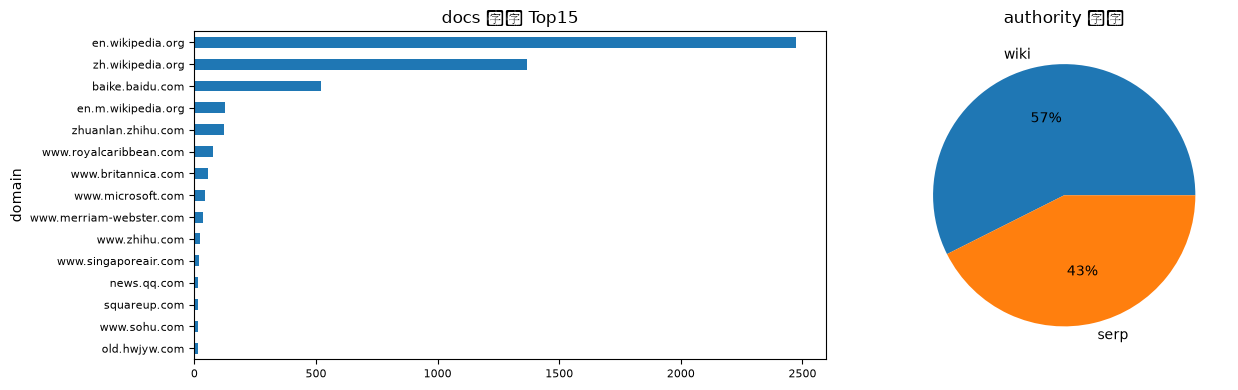

wiki 占比 65% ｜ 图文绑定页 27% ｜ 零段页 0


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
top = docs.domain.value_counts().head(15)[::-1]
top.plot.barh(ax=ax[0], title='docs 域名 Top15', fontsize=8)
docs.authority.value_counts().plot.pie(ax=ax[1], autopct='%.0f%%', title='authority 分布')
plt.tight_layout(); plt.show()
wiki = docs.domain.str.contains('wikipedia').mean()
print(f'wiki 占比 {wiki:.0%} ｜ 图文绑定页 {(docs.n_images > 0).mean():.0%} ｜ 零段页 {(docs.n_passages == 0).sum()}')

## 2. 段落绑定质量（n_passages 分布 + 壳页抽样）

/tmp/ipykernel_1548945/1765267068.py:4: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548945/1765267068.py:4: UserWarning: Glyph 39029 (\N{CJK UNIFIED IDEOGRAPH-9875}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548945/1765267068.py:4: UserWarning: Glyph 32465 (\N{CJK UNIFIED IDEOGRAPH-7ED1}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548945/1765267068.py:4: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548945/1765267068.py:4: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548945/1765267068.py:4: UserWarning: Glyph 33853 (\N{CJK UNIFIED IDEOGRAPH-843D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipyke

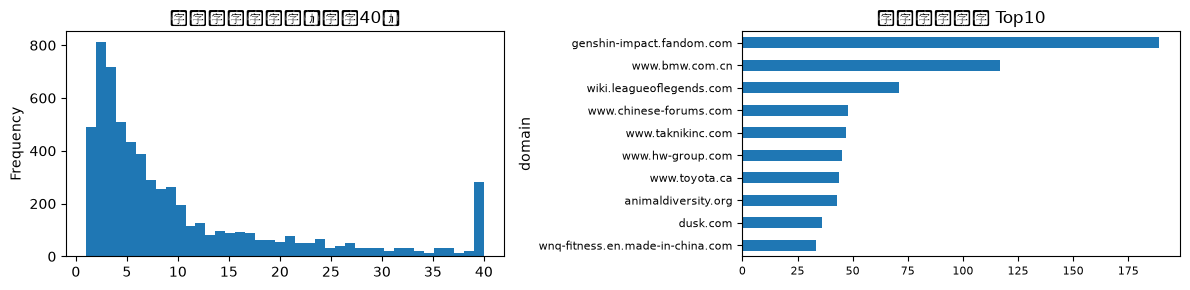

抽样 40 页：壳页率（<2000B）8%，读取失败 0 页


,domain,title,page_bytes
949,en.wikipedia.org,Golden Eagle Award for Best Actress (China),1785
3271,zh.wikipedia.org,上海杜莎夫人蜡像馆,1788
4512,zh.wikipedia.org,特斯拉,701


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
docs.n_passages.clip(upper=40).plot.hist(bins=40, ax=ax[0], title='每页绑定段落数（截断40）')
docs.groupby('domain').n_passages.median().sort_values(ascending=False).head(10)[::-1].plot.barh(ax=ax[1], title='各域中位段数 Top10', fontsize=8)
plt.tight_layout(); plt.show()

SHELL_BYTES = 2000   # 小于此字节的页文件疑似壳页
DS_ROOT = PAGES_ROOT.parent   # path 字段形如 pages/xx/sha.md（相对 datasets/demiwtg）
sample = docs.sample(min(40, len(docs)), random_state=7)
sizes = []
for _, r in sample.iterrows():
    f = DS_ROOT / r.path if r.path else PAGES_ROOT / (r.page_sha[:2] + '/' + r.page_sha + '.md')
    sizes.append(f.stat().st_size if f.exists() else -1)
sample = sample.assign(page_bytes=sizes)
shell = (sample.page_bytes < SHELL_BYTES).mean()
print(f'抽样 {len(sample)} 页：壳页率（<{SHELL_BYTES}B）{shell:.0%}，读取失败 {(sample.page_bytes < 0).sum()} 页')
sample.loc[sample.page_bytes < SHELL_BYTES, ['domain', 'title', 'page_bytes']]

## 3. 随机深读 N 页（人工 review 用）

In [5]:
def show_page(row, chars=400):
    f = DS_ROOT / row.path if row.path else PAGES_ROOT / (row.page_sha[:2] + '/' + row.page_sha + '.md')
    print(f"### {row.title}\n{row.url}\n概念: {row.concepts}｜段{row.n_passages} 图{row.n_images}｜{row._shard}\n---")
    print(f.read_text()[:chars] if f.exists() else '(页文件缺失)')
    print()

for _, r in docs.sample(3, random_state=42).iterrows():
    show_page(r)

### 环法自行车赛
https://zh.wikipedia.org/wiki/环法自行车赛
概念: ['环法自行车赛']｜段19 图0｜A(0/3)
---
環法自行車賽（法語：Le Tour de France）是一个每年举办的多赛段公路單車賽，主要在法國进行，但有时也出入周邊國家（如義大利、比利時、西班牙、荷兰）。自從1903年開始以來，每年於夏季举行，每次賽期23天，平均賽程約3000至3500公里（約2200英里）。完整賽程每年不一，但大都大体上環繞法國一周。截至2020年代，比賽結束前總是會穿越巴黎市中心的香榭丽舍大道，並且經過艾菲爾鐵塔。比赛全程分成許多段，從一個城鎮到下一個，每一段分別計時排名。所有段成績累計起來決定每一位賽手的總成績，总冠軍為各段時間累計最少者。在每日賽事結束時，領先者將可穿上黄色领骑衫，最佳衝刺者將被贈與一件綠色車衣，山間賽事中之最佳騎手將會得到一件波爾卡點運動衣，其有時被稱作登山王。
像其他公路大賽一樣，選手們組織隊伍參賽。每一隊由8名選手組成(2018以前為9名)，共有20至22個小隊。傳統上，只有一流的專

### Raffinose
https://en.wikipedia.org/wiki/Raffinose
概念: ['棉子糖']｜段9 图0｜A(0/3)
---
Raffinose is a trisaccharide derived from galactose, glucose, and fructose. Raffinose can be hydrolyzed to D-galactose and sucrose by the enzyme alpha galactosidase (α-GAL), an enzyme synthesized by bacteria found in the large intestine. α-GAL also hydrolyzes other alpha galactosides such as stachyose, verbascose, and galactinol, if present. In plants, raffinose plays a significant role in stress 

### 斯圖爾特
https://zh.wikipedia.or

[跳转到内容](https://zh.wikipedia.org/wiki/%E6%96%AF%E5%9C%96%E7%88%BE%E7%89%B9#bodyContent)
主菜单
主菜单
移至侧栏 隐藏
导航 
  * [首页](https://zh.wikipedia.org/wiki/Wikipedia:%E9%A6%96%E9%A1%B5 "访问首页​\[alt-z\]")
  * [分类索引](https://zh.wikipedia.org/wiki/Wikipedia:%E5%88%86%E7%B1%BB%E7%B4%A2%E5%BC%95 "以分类索引搜寻中文维基百科")
  * [特色内容](https://zh.wikipedia.org/wiki/Portal:%E7%89%B9%E8%89%B2%E5%85%A7%E5%AE%B9 "查看中文维基百科的特色内容")



## 4. 图像：源分布 / 每概念图数 / 重复检测

/tmp/ipykernel_1548945/2374984766.py:6: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548945/2374984766.py:6: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548945/2374984766.py:6: UserWarning: Glyph 28304 (\N{CJK UNIFIED IDEOGRAPH-6E90}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548945/2374984766.py:6: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548945/2374984766.py:6: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1548945/2374984766.py:6: UserWarning: Glyph 24565 (\N{CJK UNIFIED IDEOGRAPH-5FF5}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipyke

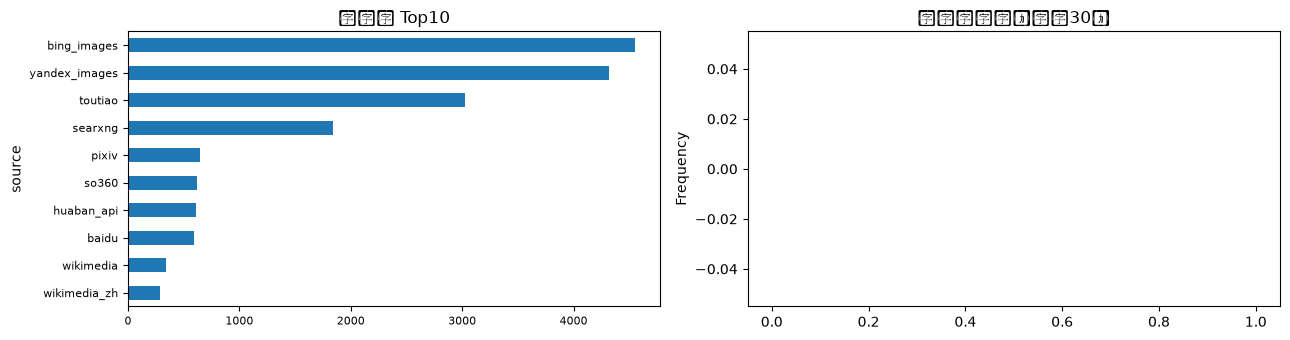

重复 sha256: 742 行（4.4%）


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
imgs['source'] = imgs.get('source', imgs.get('engine', pd.Series('?' * len(imgs))))
imgs.source.value_counts().head(10)[::-1].plot.barh(ax=ax[0], title='图像源 Top10', fontsize=8)
per_concept = imgs.groupby(imgs['queries'].map(lambda q: q[0] if isinstance(q, list) and q else None)).size()
per_concept.clip(upper=30).plot.hist(bins=30, ax=ax[1], title='每概念图数（截断30）')
plt.tight_layout(); plt.show()

for col in ('sha256', 'image_sha', 'blob_sha', 'sha', 'content_url'):
    if col in imgs.columns:
        dup = imgs[col].duplicated().sum()
        print(f'重复 {col}: {dup} 行（{dup/len(imgs):.1%}）'); break
else:
    print('可用列:', imgs.columns.tolist())

## 5. 概念覆盖交叉（有图 / 有 docs / 双缺）

In [7]:
docs_c = set(docs.concepts.explode()) if docs.concepts.apply(lambda x: isinstance(x, list)).all() else set(docs.concepts)
img_c = set(imgs.queries.explode().dropna()) if 'queries' in imgs else set()
both, only_i, only_d, neither = len(img_c & docs_c), len(img_c - docs_c), len(docs_c - img_c), '—'
print(f'有图概念 {len(img_c)}｜有docs概念 {len(docs_c)}｜交集 {both}｜仅图 {only_i}｜仅docs {only_d}')
print('仅 docs 无图的概念样例（wiki 0绑定图问题相关）:', list(docs_c - img_c)[:10])

有图概念 282｜有docs概念 263｜交集 262｜仅图 20｜仅docs 1
仅 docs 无图的概念样例（wiki 0绑定图问题相关）: ['蜜露']


## 6. 商业域复核清单（-40 惩罚效果验证）

In [8]:
COMMERCIAL = ('amazon.', 'ebay.', 'taobao.', 'jd.com', 'tmall.', 'bolt.eu', 'aliexpress', 'walmart.')
comm = docs[docs.domain.str.contains('|'.join(COMMERCIAL), na=False)]
print(f'商业域混入页: {len(comm)}')
comm[['domain', 'title', 'n_passages']].head(10)

商业域混入页: 20


,domain,title,n_passages
926,www.taobao.com,海竿 - Top 5万件海竿 - 2026年9月更新 - 淘宝Taobao｜天猫Tmall,1
1566,www.taobao.com,平衡木 - Top 1000件平衡木 - 2026年9月更新 - 淘宝Taobao ...,1
1818,item.m.jd.com,土壤采样瓶VOC棕色广口玻璃瓶样品瓶土壤瓶60 100 250 ... - 京东,4
1856,www.amazon.com,Amazon.com: Treadmill,4
1864,www.amazon.com,Amazon.com: One-way Mirror,3
1874,www.amazon.com,Amazon Best Sellers: Best Diabetic Test Strips,2
2860,www.taobao.com,海竿 - Top 5万件海竿 - 2026年9月更新 - 淘宝Taobao｜天猫Tmall,1
3319,item.m.jd.com,海竿钓鱼竿套装抛竿甩竿远投竿超硬海钓竿海杆全套鱼杆渔具2.1m m3 ...,5
3571,www.taobao.com,平衡木 - Top 1000件平衡木 - 2026年9月更新 - 淘宝Taobao ...,1
3815,cread.jd.com,动物博物馆-- （法）希尔维·贝居埃尔-京东阅读,8


## 7. 采集时间线（fetch 速率是否健康）

/home/ubuntu/demi/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/demi/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/demi/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/demi/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 33853 (\N{CJK UNIFIED IDEOGRAPH-843D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/demi/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 30424 (\N{CJK UNIFIE

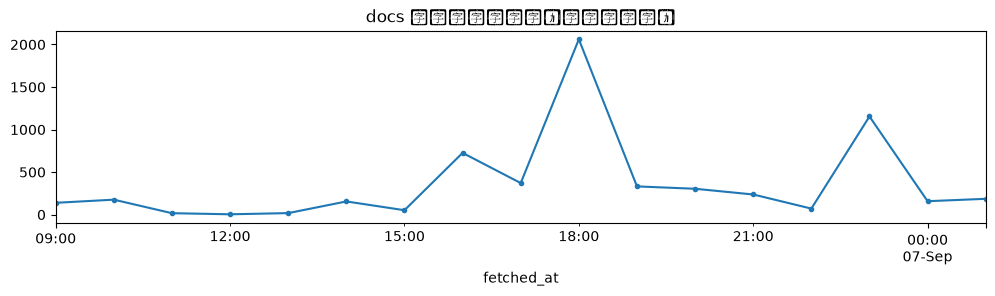

注意 23:25Z 后应有显著抬升（supervise 双清单修复释放 docs 产能）


In [9]:
ts = pd.to_datetime(docs.fetched_at, errors='coerce', unit='s', origin='unix') if docs.fetched_at.dtype != object else pd.to_datetime(docs.fetched_at, errors='coerce')
ts = ts.dropna()
if len(ts):
    per_h = ts.dt.floor('h').value_counts().sort_index()
    per_h.plot(figsize=(12, 2.5), title='docs 每小时落盘页数（全分片合计）', marker='.')
    plt.show()
    print('注意 23:25Z 后应有显著抬升（supervise 双清单修复释放 docs 产能）')